# Spatial Transcriptomics DE Pipeline — Half Brain
**QC rule:** a gene is kept if detected in ≥ 3 spots in ≥ 3 of 4 samples
within **at least one** experimental group.

**Workflow:**
0. Imports & Setup
1. Read Visium data → individual h5ad
2. Concatenate into unified AnnData
3. Quality Control (violin plots before & after)
4. Normalization
5. Feature Selection (HVGs)
7. PCA-Loading Gene Filtering
8. Clustering & UMAP
9. Pseudobulk Construction
10. Differential Expression (Welch t-test)
11. Volcano Plots
12. Summary

## 0 · Imports & Setup

In [1]:
import scanpy as sc
import squidpy as sq
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import sparse, stats
from statsmodels.stats.multitest import multipletests
from kneed import KneeLocator
import os, shutil, warnings

try:
    from adjustText import adjust_text
    _HAS_ADJUSTTEXT = True
    print("✓ adjustText loaded — volcano labels will be auto-repelled")
except ImportError:
    _HAS_ADJUSTTEXT = False
    print("⚠ adjustText not installed — using manual offset for volcano labels")
    print("  Install with: pip install adjustText")

warnings.filterwarnings("ignore", category=FutureWarning)
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=150, facecolor="white", frameon=False)


⚠ adjustText not installed — using manual offset for volcano labels
  Install with: pip install adjustText


In [ ]:

# --- Paths -------------------------------------------------------------------
VISIUM_INPUT_FOLDER          = "/opt/Data/RNA Seq 2025 Hippocampus"
H5AD_OUTPUT_PATH             = "/home/ajarrah/PhD_Thesis/gene_paper/h5ad_data_hippocampus/"
AGGREGATED_H5AD_OUTPUT_PATH  = "/home/ajarrah/PhD_Thesis/gene_paper/aggregated_h5ad_data_hippocampus/"
FILE_NAME_LIST_CSV           = "/home/ajarrah/PhD_Thesis/gene_paper/csv_data/file_name_list_hippocampus.csv"
FIGURE_DIR                   = f"figures_hippocampus_all"
RESULTS_DIR                  = f"results_hippocampus_all"


SAVE_AGGREGATED = False

for d in [H5AD_OUTPUT_PATH, AGGREGATED_H5AD_OUTPUT_PATH, FIGURE_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

sc.settings.figdir = FIGURE_DIR


In [3]:
# --- Sample definitions (single source of truth) -----------------------------
SAMPLE_DEFS = {
    "A1_Young_Control_Mouse_Brain_202502": ("YC_1",  "YC",  "Control", "Young", "1-1"),
    "B1_Young_Control_Mouse_Brain_202502": ("YC_2",  "YC",  "Control", "Young", "1-2"),
    "C1_Young_Control_Mouse_Brain_202502": ("YC_3",  "YC",  "Control", "Young", "1-3"),
    "D1_Young_Control_Mouse_Brain_202502": ("YC_4",  "YC",  "Control", "Young", "1-4"),
    "A1_Young_AD_Mouse_Brain_202502":      ("YAD_1", "YAD", "AD",      "Young", "2-1"),
    "B1_Young_AD_Mouse_Brain_202502":      ("YAD_2", "YAD", "AD",      "Young", "2-2"),
    "C1_Young_AD_Mouse_Brain_202502":      ("YAD_3", "YAD", "AD",      "Young", "2-3"),
    "D1_Young_AD_Mouse_Brain_202502":      ("YAD_4", "YAD", "AD",      "Young", "2-4"),
    "A1_Aged_Control_Mouse_Brain_202502":  ("AC_1",  "AC",  "Control", "Aged",  "3-1"),
    "B1_Aged_Control_Mouse_Brain_202502":  ("AC_2",  "AC",  "Control", "Aged",  "3-2"),
    "C1_Aged_Control_Mouse_Brain_202502":  ("AC_3",  "AC",  "Control", "Aged",  "3-2"),
    "D1_Aged_Control_Mouse_Brain_202502":  ("AC_4",  "AC",  "Control", "Aged",  "3-4"),
    "A1_Aged_AD_Mouse_Brain_202502":       ("AAD_1", "AAD", "AD",      "Aged",  "4-1"),
    "B1_Aged_AD_Mouse_Brain_202502":       ("AAD_2", "AAD", "AD",      "Aged",  "4-2"),
    "C1_Aged_AD_Mouse_Brain_202502":       ("AAD_3", "AAD", "AD",      "Aged",  "4-3"),
    "D1_Aged_AD_Mouse_Brain_202502":       ("AAD_4", "AAD", "AD",      "Aged",  "4-4"),
}

SAMPLE_ORDER = [
    "YC_1",  "YC_2",  "YC_3",  "YC_4",
    "YAD_1", "YAD_2", "YAD_3", "YAD_4",
    "AC_1",  "AC_2",  "AC_3",  "AC_4",
    "AAD_1", "AAD_2", "AAD_3", "AAD_4",
]

SHORT_TO_ORIG = {v[0]: k for k, v in SAMPLE_DEFS.items()}


In [4]:
# --- User-defined comparisons ------------------------------------------------
COMPARISONS = [
    {
        "name": "AD_vs_Control",
        "desc": "All AD vs All Control",
        "group1_filter": {"Condition": "AD"},
        "group2_filter": {"Condition": "Control"},
    },
    {
        "name": "Aged_vs_Young",
        "desc": "All Aged vs All Young",
        "group1_filter": {"Age": "Aged"},
        "group2_filter": {"Age": "Young"},
    },
    {
        "name": "YAD_vs_YC",
        "desc": "Young AD vs Young Control",
        "group1_filter": {"Age": "Young", "Condition": "AD"},
        "group2_filter": {"Age": "Young", "Condition": "Control"},
    },
    {
        "name": "AAD_vs_AC",
        "desc": "Aged AD vs Aged Control",
        "group1_filter": {"Age": "Aged", "Condition": "AD"},
        "group2_filter": {"Age": "Aged", "Condition": "Control"},
    },
    {
        "name": "AC_vs_YC",
        "desc": "Aged Control vs Young Control (aging effect)",
        "group1_filter": {"Age": "Aged",  "Condition": "Control"},
        "group2_filter": {"Age": "Young", "Condition": "Control"},
    },
    {
        "name": "AAD_vs_YAD",
        "desc": "Aged AD vs Young AD",
        "group1_filter": {"Age": "Aged",  "Condition": "AD"},
        "group2_filter": {"Age": "Young", "Condition": "AD"},
    },
]


In [5]:
# --- Helper functions ---------------------------------------------------------

_PALETTE = [
    "#c0392b", "#2980b9", "#8e44ad", "#27ae60", "#d35400",
    "#2c3e50", "#16a085", "#e67e22", "#1abc9c", "#e74c3c",
]
comp_labels = {c["name"]: c["desc"] for c in COMPARISONS}
comp_colors = {c["name"]: _PALETTE[i % len(_PALETTE)]
               for i, c in enumerate(COMPARISONS)}


def build_mask(obs_df, filt):
    mask = pd.Series(True, index=obs_df.index)
    for col, val in filt.items():
        if col not in obs_df.columns:
            raise KeyError(f"Filter column '{col}' not found. Available: {list(obs_df.columns)}")
        if isinstance(val, (list, tuple)):
            mask &= obs_df[col].isin(val)
        else:
            mask &= obs_df[col] == val
    return mask


def describe_filter(filt):
    parts = []
    for col, val in filt.items():
        if isinstance(val, (list, tuple)):
            parts.append(f"{col}∈{{{', '.join(val)}}}")
        else:
            parts.append(f"{col}={val}")
    return " & ".join(parts)


def check_disk_space(path, required_gb=1.0):
    try:
        usage = shutil.disk_usage(os.path.dirname(os.path.abspath(path)))
        free_gb = usage.free / (1024 ** 3)
        print(f"  Disk space available at {path}: {free_gb:.1f} GB")
        if free_gb < required_gb:
            print(f"  ⚠ WARNING: Less than {required_gb} GB free!")
            return False
        return True
    except Exception:
        return True


def safe_write_h5ad(adata_obj, filepath, compression="gzip"):
    check_disk_space(filepath, required_gb=0.5)
    try:
        adata_obj.write(filepath, compression=compression)
        print(f"  ✓ Saved: {filepath}")
    except OSError as e:
        print(f"  ✗ WRITE FAILED: {e}")
        if os.path.exists(filepath):
            os.remove(filepath)
        raise


## 1 · Read Visium Data → Individual h5ad Files

In [6]:
file_name_list = sorted(os.listdir(VISIUM_INPUT_FOLDER))
pd.DataFrame(file_name_list, columns=["file_name"]).to_csv(FILE_NAME_LIST_CSV, index=False)
print(f"Found {len(file_name_list)} samples in {VISIUM_INPUT_FOLDER}")

for sample_folder in file_name_list:
    if sample_folder not in SAMPLE_DEFS:
        print(f"  ⚠ Skipping unrecognized folder: {sample_folder}")
        continue

    short_key, group, condition, age, code_id = SAMPLE_DEFS[sample_folder]
    out_path = os.path.join(H5AD_OUTPUT_PATH, f"{sample_folder}.h5ad")

    if os.path.exists(out_path):
        print(f"  Skipping {sample_folder} -> {short_key} (already exists)")
        continue

    print(f"  Reading {sample_folder} -> {short_key}")
    a = sc.read_visium(os.path.join(VISIUM_INPUT_FOLDER, sample_folder, "outs"))
    a.obs["Original_Name"] = sample_folder
    a.obs["Sample_Code"]   = code_id
    a.obs["Group"]         = group
    a.var_names_make_unique()
    safe_write_h5ad(a, out_path)
    del a


Found 16 samples in /opt/Data/RNA Seq 2025 Hippocampus
  Skipping A1_Aged_AD_Mouse_Brain_202502 -> AAD_1 (already exists)
  Skipping A1_Aged_Control_Mouse_Brain_202502 -> AC_1 (already exists)
  Skipping A1_Young_AD_Mouse_Brain_202502 -> YAD_1 (already exists)
  Skipping A1_Young_Control_Mouse_Brain_202502 -> YC_1 (already exists)
  Skipping B1_Aged_AD_Mouse_Brain_202502 -> AAD_2 (already exists)
  Skipping B1_Aged_Control_Mouse_Brain_202502 -> AC_2 (already exists)
  Skipping B1_Young_AD_Mouse_Brain_202502 -> YAD_2 (already exists)
  Skipping B1_Young_Control_Mouse_Brain_202502 -> YC_2 (already exists)
  Skipping C1_Aged_AD_Mouse_Brain_202502 -> AAD_3 (already exists)
  Skipping C1_Aged_Control_Mouse_Brain_202502 -> AC_3 (already exists)
  Skipping C1_Young_AD_Mouse_Brain_202502 -> YAD_3 (already exists)
  Skipping C1_Young_Control_Mouse_Brain_202502 -> YC_3 (already exists)
  Skipping D1_Aged_AD_Mouse_Brain_202502 -> AAD_4 (already exists)
  Skipping D1_Aged_Control_Mouse_Brain_20250

## 2 · Concatenate into Unified AnnData

In [7]:
adatas_for_agg = [] if SAVE_AGGREGATED else None
adatas_for_analysis = []

for short_key in SAMPLE_ORDER:
    orig_name = SHORT_TO_ORIG[short_key]
    _, group, condition, age, code_id = SAMPLE_DEFS[orig_name]
    filepath = os.path.join(H5AD_OUTPUT_PATH, f"{orig_name}.h5ad")

    a = sc.read_h5ad(filepath)

    if SAVE_AGGREGATED:
        adatas_for_agg.append(a.copy())

    a.obs["Sample"]    = short_key
    a.obs["Group"]     = group
    a.obs["Condition"] = condition
    a.obs["Age"]       = age
    a.obs_names = [f"{short_key}_{x}" for x in a.obs_names]
    a.obs_names_make_unique()
    adatas_for_analysis.append(a)

if SAVE_AGGREGATED:
    print("Building aggregated spatial object...")
    adata_agg = sc.concat(
        adatas_for_agg, label="Sample", keys=SAMPLE_ORDER, uns_merge="unique"
    )
    for short_key, a_orig in zip(SAMPLE_ORDER, adatas_for_agg):
        if "spatial" not in a_orig.uns:
            continue
        inner_key = next(iter(a_orig.uns["spatial"].keys()))
        if inner_key in adata_agg.uns.get("spatial", {}):
            spatial_dict = adata_agg.uns["spatial"]
            if short_key != inner_key:
                spatial_dict[short_key] = spatial_dict.pop(inner_key)
    agg_path = os.path.join(AGGREGATED_H5AD_OUTPUT_PATH, "aggregated_mouse_brain_202502.h5ad")
    safe_write_h5ad(adata_agg, agg_path)
    print(f"Aggregated object saved: {adata_agg.shape}")
    del adata_agg, adatas_for_agg
else:
    print("Skipping aggregated h5ad save (SAVE_AGGREGATED=False).")

adata = ad.concat(adatas_for_analysis, join="inner", merge="first")
adata.obs_names_make_unique()
del adatas_for_analysis
print(f"Analysis object: {adata.shape}")


Skipping aggregated h5ad save (SAVE_AGGREGATED=False).
Analysis object: (6488, 32285)


## 3 · Quality Control

### 3a — QC Metrics BEFORE Filtering

In [8]:
# --- Remove all-zero genes ---------------------------------------------------
if sparse.issparse(adata.X):
    mask = np.array(adata.X.sum(axis=0) != 0).ravel()
else:
    mask = adata.X.sum(axis=0) != 0
adata = adata[:, mask].copy()

# --- Mitochondrial & ribosomal flags -----------------------------------------
adata.var["mt"]   = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.match("^(Rpl|Rps)")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True)

print(f"Shape before QC filtering: {adata.shape}")


Shape before QC filtering: (6488, 21560)


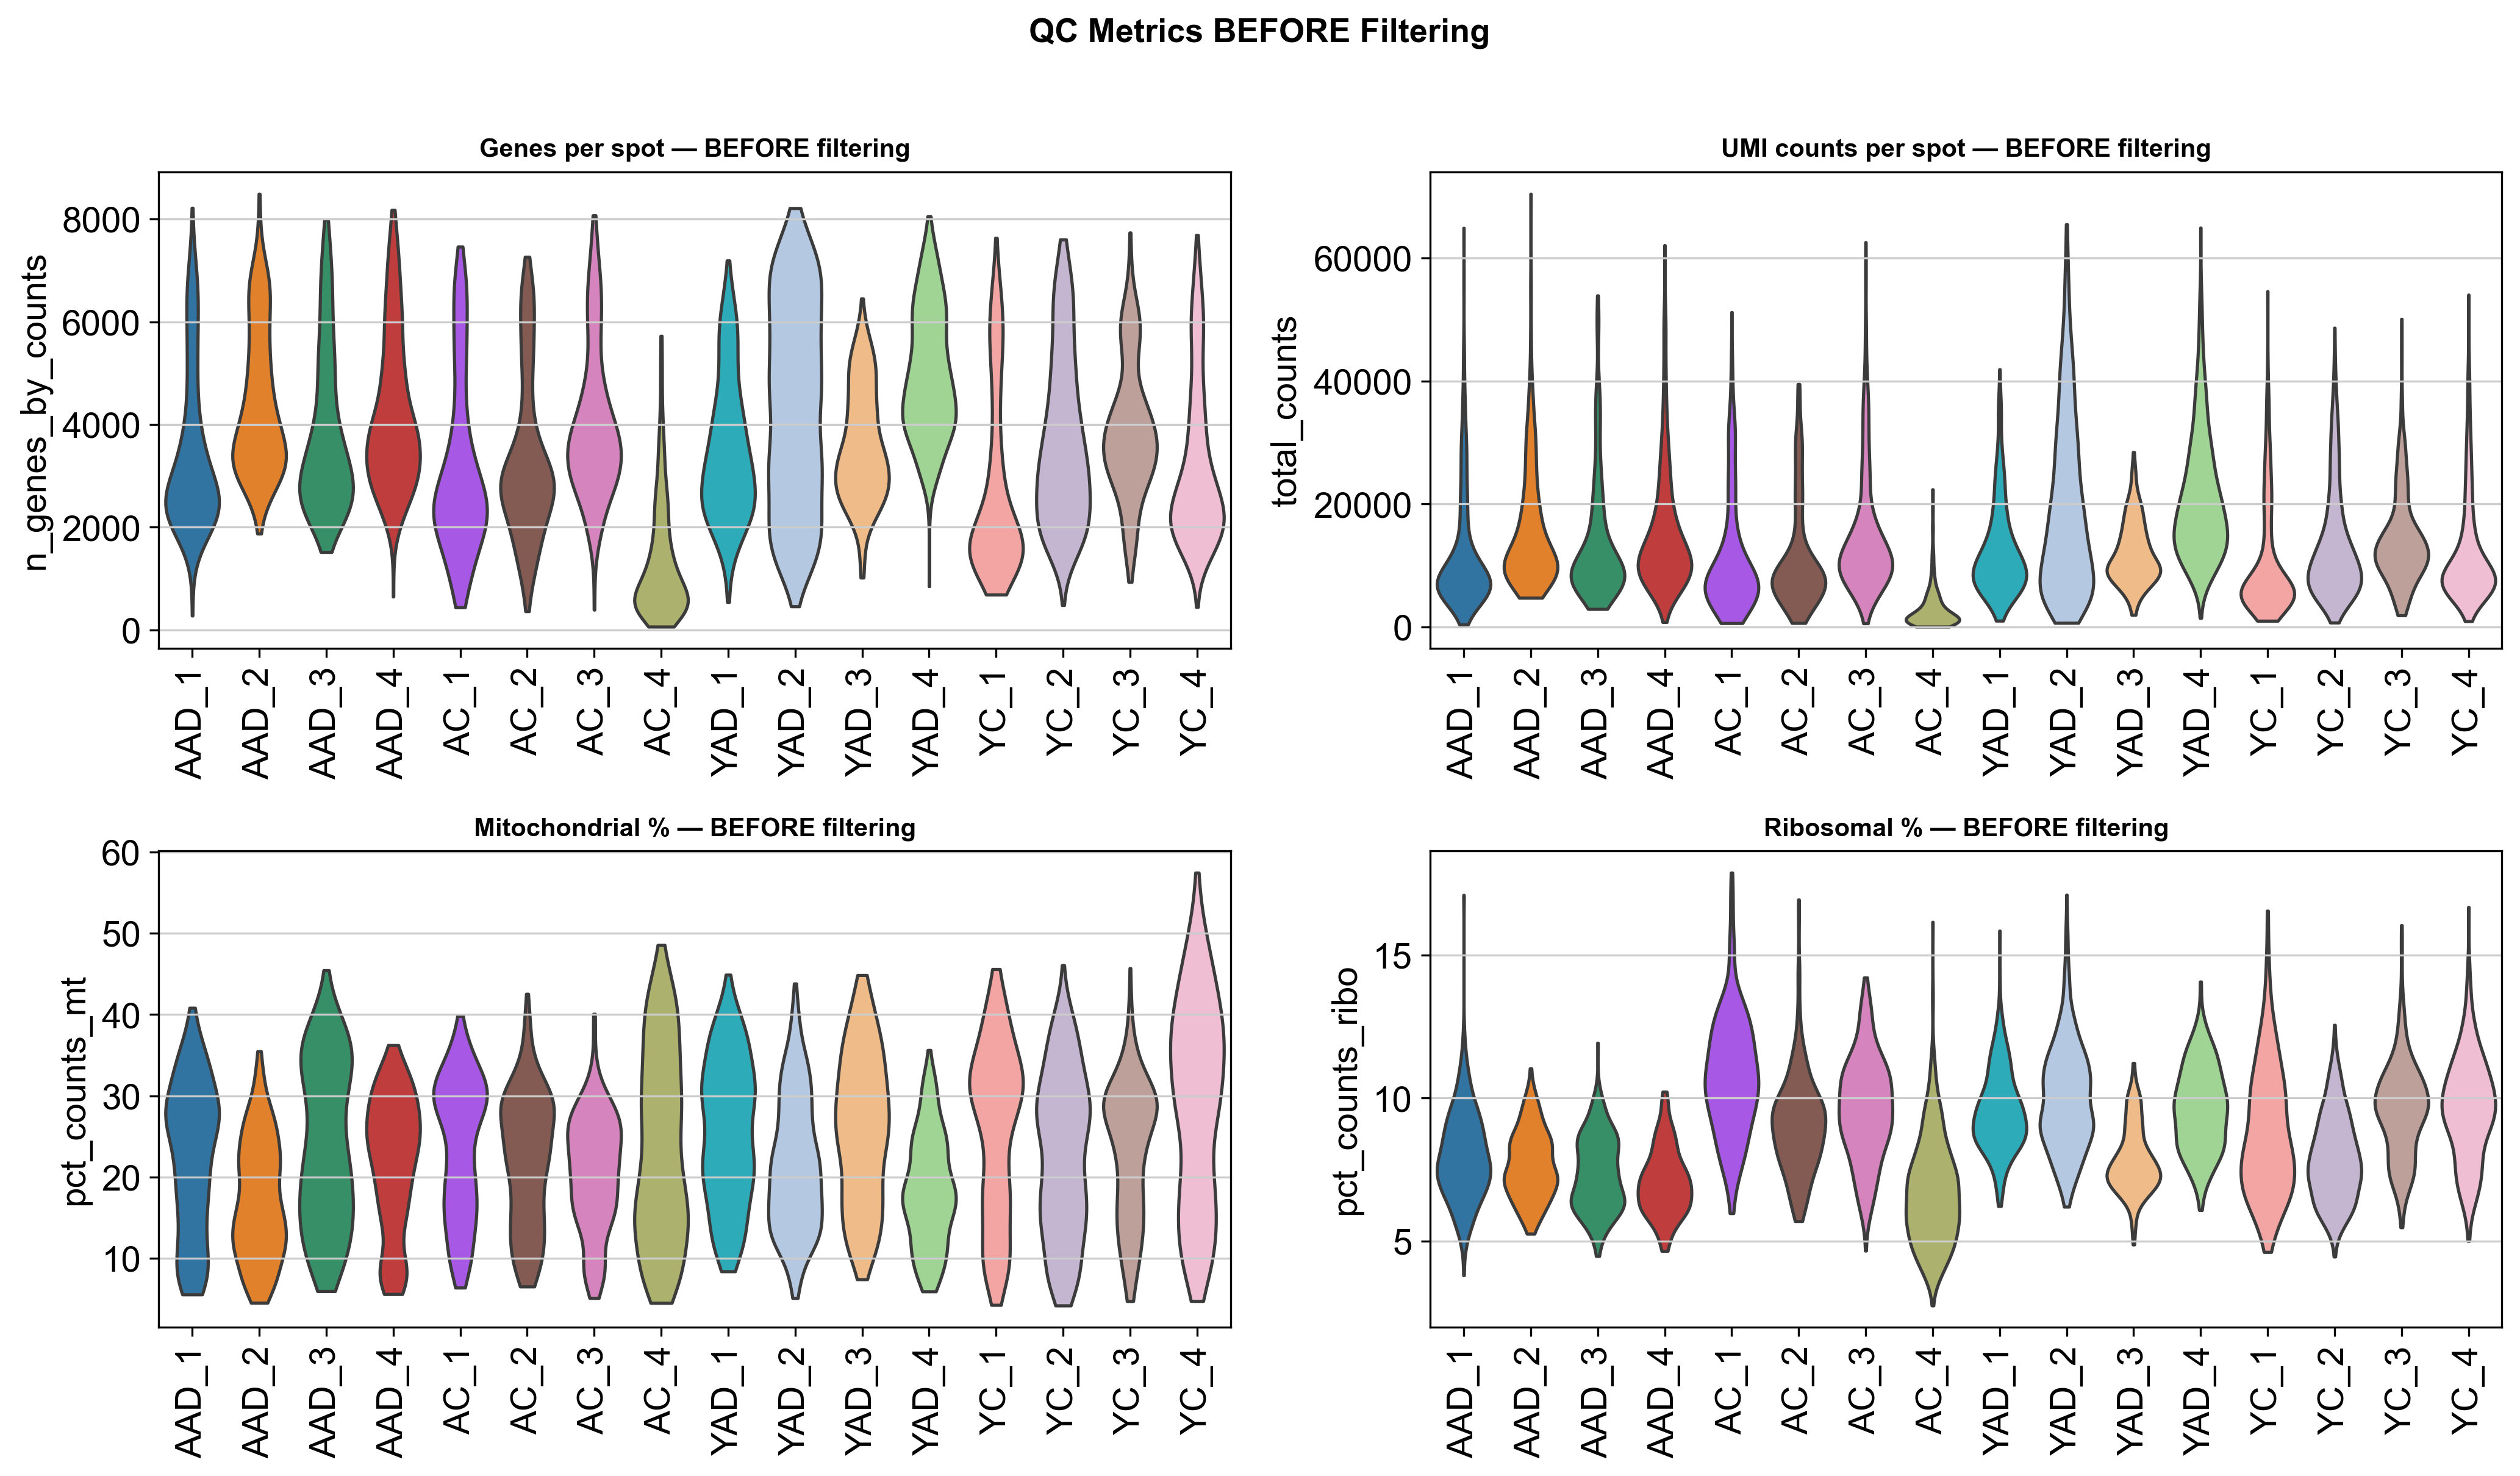

In [9]:
# --- Violin plots BEFORE filtering -------------------------------------------
qc_keys = ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"]
qc_titles = ["Genes per spot", "UMI counts per spot", "Mitochondrial %", "Ribosomal %"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, key, title in zip(axes, qc_keys, qc_titles):
    sc.pl.violin(adata, key, groupby="Sample", rotation=90, ax=ax, show=False,
                 stripplot=False)
    ax.set_title(f"{title} — BEFORE filtering", fontsize=10, fontweight="bold")
    ax.set_ylabel(key)

plt.suptitle("QC Metrics BEFORE Filtering", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 3b — Apply Filters

In [10]:
# --- Cell/spot filter --------------------------------------------------------
sc.pp.filter_cells(adata, min_genes=200)

# --- Gene QC parameters ------------------------------------------------------
MIN_SPOTS            = 3   # spots per sample for a gene to "count"
MIN_SAMPLES_IN_GROUP = 3   # samples within a group that must pass

# --- Gene filter: ≥ MIN_SPOTS spots in ≥ MIN_SAMPLES_IN_GROUP samples -------
#     within AT LEAST ONE group (YC / YAD / AC / AAD)
# ---------------------------------------------------------------------------
GROUP_KEY  = "Group"
SAMPLE_KEY = "Sample"

groups  = adata.obs[GROUP_KEY].unique()
n_genes = adata.n_vars

gene_passes_any_group = np.zeros(n_genes, dtype=bool)

print(f"\n  Gene filter: ≥{MIN_SPOTS} spots in ≥{MIN_SAMPLES_IN_GROUP} samples "
      f"within at least 1 of {len(groups)} groups")

for group in sorted(groups):
    group_obs   = adata.obs[GROUP_KEY] == group
    group_adata = adata[group_obs]
    samples     = group_adata.obs[SAMPLE_KEY].unique()

    samples_passing = np.zeros(n_genes, dtype=int)
    for sample in samples:
        sample_obs   = group_adata.obs[SAMPLE_KEY] == sample
        sample_adata = group_adata[sample_obs]
        spot_counts  = np.asarray((sample_adata.X > 0).sum(axis=0)).ravel()
        samples_passing += (spot_counts >= MIN_SPOTS).astype(int)

    group_pass = samples_passing >= MIN_SAMPLES_IN_GROUP
    gene_passes_any_group |= group_pass

    print(f"    {group:>5}: {group_pass.sum():>6,} genes pass "
          f"(≥{MIN_SPOTS} spots in ≥{MIN_SAMPLES_IN_GROUP}/{len(samples)} samples)")

n_before = adata.n_vars
adata    = adata[:, gene_passes_any_group].copy()
n_after  = adata.n_vars

print(f"\n  Genes before filter : {n_before:,}")
print(f"  Genes retained      : {n_after:,}  "
      f"({100 * n_after / n_before:.1f}% of pre-filter genes)")
print(f"  Genes removed       : {n_before - n_after:,}")

# --- Recalculate QC metrics after gene filter --------------------------------
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True)

print(f"\nAfter QC: {adata.shape}")


filtered out 16 cells that have less than 200 genes expressed

  Gene filter: ≥3 spots in ≥3 samples within at least 1 of 4 groups
      AAD: 14,213 genes pass (≥3 spots in ≥3/4 samples)
       AC: 13,985 genes pass (≥3 spots in ≥3/4 samples)
      YAD: 14,535 genes pass (≥3 spots in ≥3/4 samples)
       YC: 14,127 genes pass (≥3 spots in ≥3/4 samples)

  Genes before filter : 21,560
  Genes retained      : 15,050  (69.8% of pre-filter genes)
  Genes removed       : 6,510

After QC: (6472, 15050)


### 3c — QC Metrics AFTER Filtering

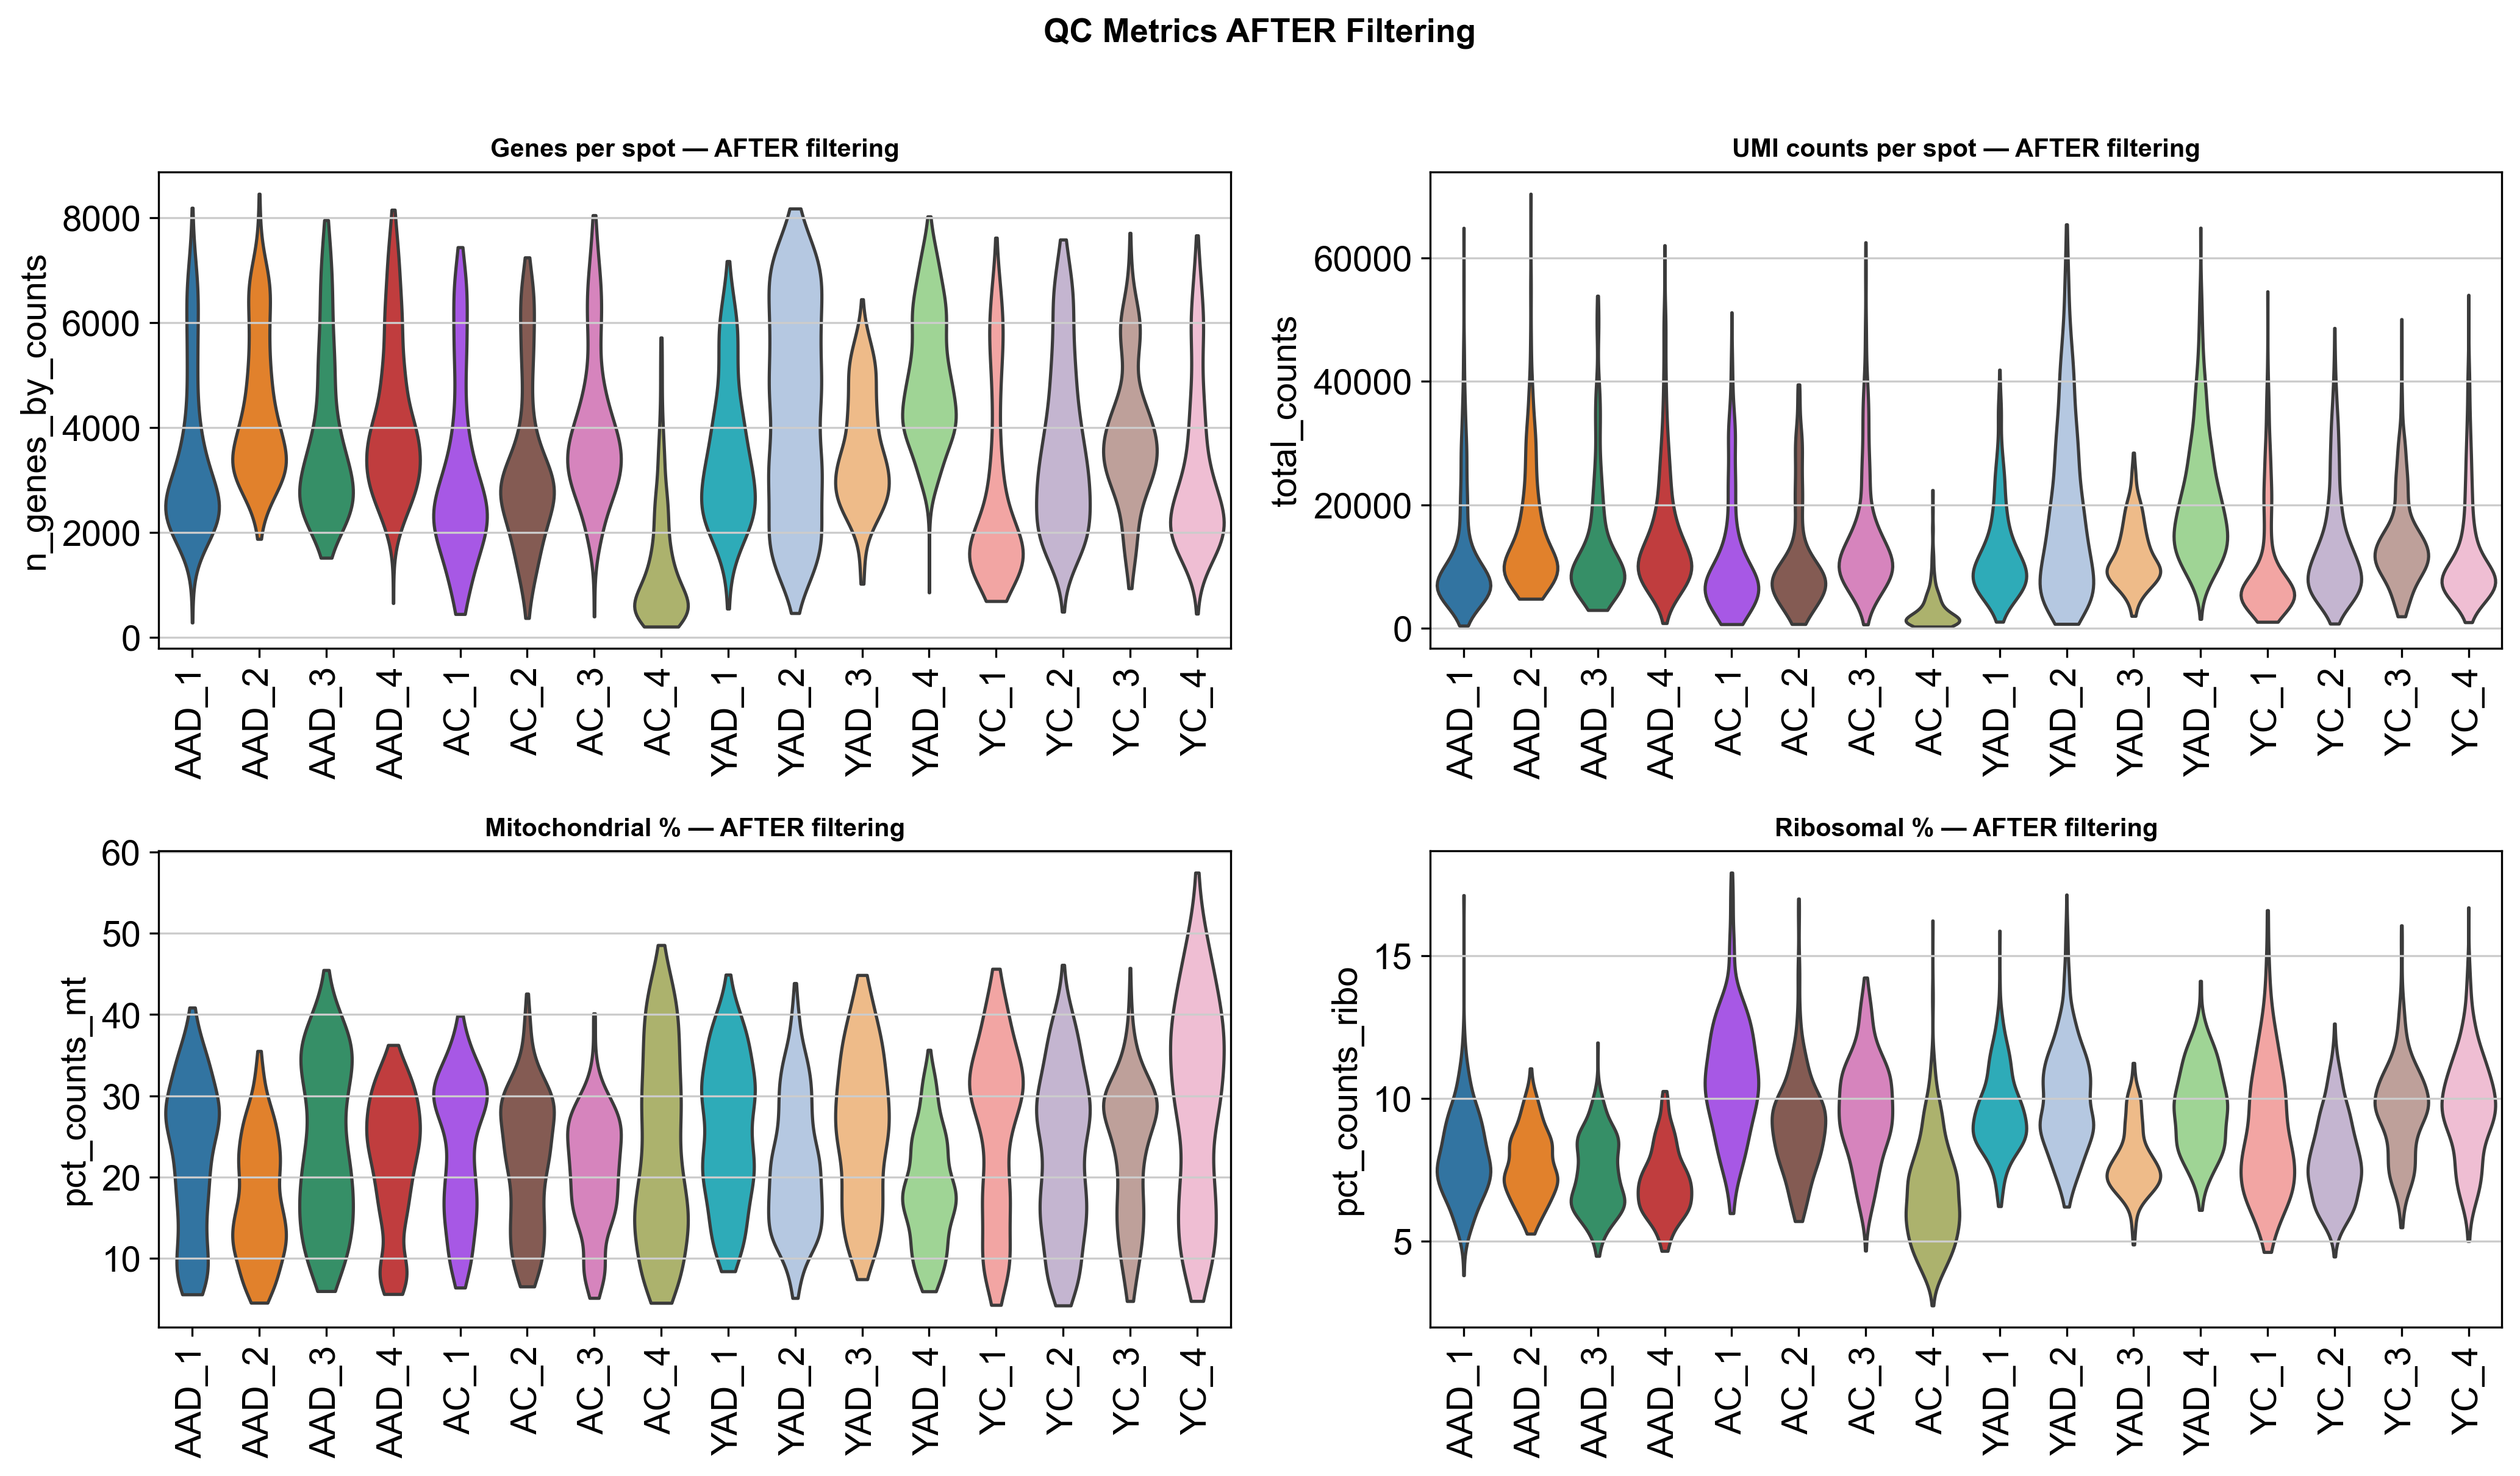

In [11]:
# --- Violin plots AFTER filtering --------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, key, title in zip(axes, qc_keys, qc_titles):
    sc.pl.violin(adata, key, groupby="Sample", rotation=90, ax=ax, show=False,
                 stripplot=False)
    ax.set_title(f"{title} — AFTER filtering", fontsize=10, fontweight="bold")
    ax.set_ylabel(key)

plt.suptitle("QC Metrics AFTER Filtering", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 4 · Normalization

In [12]:
adata.layers["raw_counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers["log_norm"] = adata.X.copy()
adata.raw = adata.copy()

print("Normalization complete (CPM 1e4 + log1p).")
print(f"  Layers: {list(adata.layers.keys())}")

normalizing counts per cell
    finished (0:00:01)
Normalization complete (CPM 1e4 + log1p).
  Layers: ['raw_counts', 'log_norm']


# Workflow A (main analysis): (My path)
* QC
* Pseudobulk Welch test
* FDR
* GSEA
# Workflow B (interpretation):
* For each of the first 10–30 PCs, extract the top positively and negatively loaded genes.
* Run pathway enrichment separately for each PC.
* Relate the PCs to age, disease, and your MSI-derived lipid features.

## 9 · Pseudobulk Construction

In [23]:
import anndata as ad
def build_pseudobulk(adata):
    samples = adata.obs["Sample"].unique()
    pb_data, pb_obs = [], []

    for sample in samples:
        mask = adata.obs["Sample"].values == sample
        if sparse.issparse(adata.layers["raw_counts"]):
            s = np.array(adata.layers["raw_counts"][mask].sum(axis=0)).ravel()
        else:
            s = adata.layers["raw_counts"][mask].sum(axis=0)
        pb_data.append(s)

        row = adata.obs.loc[mask].iloc[0]
        pb_obs.append({
            "Sample": sample,
            "Group": row["Group"],
            "Condition": row["Condition"],
            "Age": row["Age"],
            "n_spots": int(mask.sum()),
        })

    pb = ad.AnnData(
        X=np.array(pb_data, dtype=np.float32),
        obs=pd.DataFrame(pb_obs, index=samples),
        var=adata.var[[]].copy(),
    )
    return pb

pb = build_pseudobulk(adata)
pb_raw = pb.copy()

sc.pp.normalize_total(pb, target_sum=1e6)
sc.pp.log1p(pb)

print(f"Pseudobulk: {pb.shape}")
print(pb.obs[["Group", "Condition", "Age", "n_spots"]])


normalizing counts per cell
    finished (0:00:00)
Pseudobulk: (16, 15050)
      Group Condition    Age  n_spots
YC_1     YC   Control  Young      342
YC_2     YC   Control  Young      376
YC_3     YC   Control  Young      372
YC_4     YC   Control  Young      353
YAD_1   YAD        AD  Young      341
YAD_2   YAD        AD  Young      863
YAD_3   YAD        AD  Young      327
YAD_4   YAD        AD  Young      361
AC_1     AC   Control   Aged      353
AC_2     AC   Control   Aged      411
AC_3     AC   Control   Aged      399
AC_4     AC   Control   Aged      568
AAD_1   AAD        AD   Aged      357
AAD_2   AAD        AD   Aged      361
AAD_3   AAD        AD   Aged      309
AAD_4   AAD        AD   Aged      379


## 10 · Differential Expression (Welch t-test)

In [24]:
print(f"Active comparisons ({len(COMPARISONS)}):")
for c in COMPARISONS:
    g1_desc = describe_filter(c["group1_filter"])
    g2_desc = describe_filter(c["group2_filter"])
    print(f"  • {c['name']:20s}  {g1_desc}  vs  {g2_desc}")


def run_de_welch(pb, group1_mask, group2_mask, gene_list=None):
    X1 = pb[group1_mask].X
    X2 = pb[group2_mask].X

    genes = pb.var_names if gene_list is None else gene_list
    gene_idx = [list(pb.var_names).index(g) for g in genes]

    results = []
    for i, gi in enumerate(gene_idx):
        vals1 = X1[:, gi]
        vals2 = X2[:, gi]

        if np.std(vals1) == 0 and np.std(vals2) == 0:
            continue

        tstat, pval = stats.ttest_ind(vals1, vals2, equal_var=False)
        if np.isnan(pval):
            pval = 1.0

        cpm1 = np.expm1(vals1)
        cpm2 = np.expm1(vals2)
        mean1 = np.mean(cpm1)
        mean2 = np.mean(cpm2)
        log2fc = np.log2((mean1 + 1e-9) / (mean2 + 1e-9))
        mean_expr = np.mean(np.concatenate([cpm1, cpm2]))

        results.append({
            "gene": genes[i],
            "log2FC": log2fc,
            "mean_expr": mean_expr,
            "pval": pval,
        })

    df = pd.DataFrame(results)
    if df.empty:
        return df
    df["padj"] = multipletests(df["pval"], method="fdr_bh")[1]
    df["method"] = "welch"
    return df


Active comparisons (6):
  • AD_vs_Control         Condition=AD  vs  Condition=Control
  • Aged_vs_Young         Age=Aged  vs  Age=Young
  • YAD_vs_YC             Age=Young & Condition=AD  vs  Age=Young & Condition=Control
  • AAD_vs_AC             Age=Aged & Condition=AD  vs  Age=Aged & Condition=Control
  • AC_vs_YC              Age=Aged & Condition=Control  vs  Age=Young & Condition=Control
  • AAD_vs_YAD            Age=Aged & Condition=AD  vs  Age=Young & Condition=AD


In [ ]:
genes = adata.var_names[adata.var].tolist()

all_de_results = {}

print(f"PCA-filtered genes for testing: {len(genes)}\n")

for comp in COMPARISONS:
    cname = comp["name"]
    cdesc = comp["desc"]

    mask1_pb = build_mask(pb.obs, comp["group1_filter"])
    mask2_pb = build_mask(pb.obs, comp["group2_filter"])

    n1 = mask1_pb.sum()
    n2 = mask2_pb.sum()

    print(f"{'='*60}")
    print(f"DE: {cdesc}")
    print(f"  Group 1 ({describe_filter(comp['group1_filter'])}): {n1} samples")
    print(f"  Group 2 ({describe_filter(comp['group2_filter'])}): {n2} samples")

    if n1 < 2 or n2 < 2:
        print(f"  ⚠ Skipping — need ≥2 samples per side (got {n1} vs {n2})")
        continue

    df = run_de_welch(pb, mask1_pb, mask2_pb, gene_list=None)
    all_de_results[cname] = df

    sig_up = df[(df["padj"] < 0.05) & (df["log2FC"] > 0.5)].sort_values("log2FC", ascending=False)
    sig_dn = df[(df["padj"] < 0.05) & (df["log2FC"] < -0.5)].sort_values("log2FC", ascending=True)
    print(f"  Sig. up (padj<0.05, |log2FC|>0.5): {len(sig_up)}")
    print(f"  Sig. down:                          {len(sig_dn)}")


    safe_name = cdesc.replace(" ", "_").replace("/", "-")
    df.to_csv(os.path.join(RESULTS_DIR, f"DE_{cname}_{safe_name}.csv"), index=False)
    print()


PCA-filtered genes for testing: 928

DE: All AD vs All Control
  Group 1 (Condition=AD): 8 samples
  Group 2 (Condition=Control): 8 samples
  Sig. up (padj<0.05, |log2FC|>0.5): 1
  Sig. down:                          7

DE: All Aged vs All Young
  Group 1 (Age=Aged): 8 samples
  Group 2 (Age=Young): 8 samples
  Sig. up (padj<0.05, |log2FC|>0.5): 12
  Sig. down:                          10

DE: Young AD vs Young Control
  Group 1 (Age=Young & Condition=AD): 4 samples
  Group 2 (Age=Young & Condition=Control): 4 samples
  Sig. up (padj<0.05, |log2FC|>0.5): 0
  Sig. down:                          1

DE: Aged AD vs Aged Control
  Group 1 (Age=Aged & Condition=AD): 4 samples
  Group 2 (Age=Aged & Condition=Control): 4 samples
  Sig. up (padj<0.05, |log2FC|>0.5): 3
  Sig. down:                          11

DE: Aged Control vs Young Control (aging effect)
  Group 1 (Age=Aged & Condition=Control): 4 samples
  Group 2 (Age=Young & Condition=Control): 4 samples
  Sig. up (padj<0.05, |log2FC|>0.5

## 12 · Summary

In [ ]:
print("=" * 70)
print("PIPELINE SUMMARY")
print("=" * 70)
print(f"QC filter:                  ≥{MIN_SPOTS} spots in ≥{MIN_SAMPLES_IN_GROUP}/4 samples per group")
print(f"DE method:                  Welch t-test")
print(f"Total spots after QC:       {adata.n_obs:,}")
print(f"Total genes after QC:       {adata.n_vars:,}")
print(f"HVGs (Seurat v3):           {adata.var['highly_variable'].sum():,}")
print(f"PCA-filtered genes:         {adata.var['pca_filtered'].sum():,}")
print(f"Leiden clusters:            {adata.obs['leiden'].nunique()}")
print()

print(f"Comparisons run: {len(all_de_results)}")
for comp in COMPARISONS:
    cname = comp["name"]
    if cname not in all_de_results:
        print(f"  ✗ {comp['desc']} — SKIPPED")
        continue
    de = all_de_results[cname]
    n_up = de[(de["padj"] < 0.05) & (de["log2FC"] > 0.5)].shape[0]
    n_dn = de[(de["padj"] < 0.05) & (de["log2FC"] < -0.5)].shape[0]
    print(f"  ✓ {comp['desc']}:")
    print(f"      {describe_filter(comp['group1_filter'])}  vs  {describe_filter(comp['group2_filter'])}")
    print(f"      ▲ Up: {n_up}   ▼ Down: {n_dn}")
print()

print(f"Results saved to: {RESULTS_DIR}/")
print(f"Figures saved to: {FIGURE_DIR}/")
print("Pipeline complete.")


PIPELINE SUMMARY
QC filter:                  ≥3 spots in ≥3/4 samples per group
DE method:                  Welch t-test
Total spots after QC:       6,472
Total genes after QC:       15,050
HVGs (Seurat v3):           3,000
PCA-filtered genes:         928
Leiden clusters:            11

Comparisons run: 6
  ✓ All AD vs All Control:
      Condition=AD  vs  Condition=Control
      ▲ Up: 1   ▼ Down: 7
  ✓ All Aged vs All Young:
      Age=Aged  vs  Age=Young
      ▲ Up: 12   ▼ Down: 10
  ✓ Young AD vs Young Control:
      Age=Young & Condition=AD  vs  Age=Young & Condition=Control
      ▲ Up: 0   ▼ Down: 1
  ✓ Aged AD vs Aged Control:
      Age=Aged & Condition=AD  vs  Age=Aged & Condition=Control
      ▲ Up: 3   ▼ Down: 11
  ✓ Aged Control vs Young Control (aging effect):
      Age=Aged & Condition=Control  vs  Age=Young & Condition=Control
      ▲ Up: 5   ▼ Down: 5
  ✓ Aged AD vs Young AD:
      Age=Aged & Condition=AD  vs  Age=Young & Condition=AD
      ▲ Up: 3   ▼ Down: 0

Results save